# Phishing URL Detection Using Logistic Regression Classification


This notebook covers dataset acquisition, data cleaning, data transformation,
feature selection, feature engineering, data splitting, and the configuration,
training and comparison of two Logistic Regression **binary classifiers** for
detecting phishing URLs from lexical and structural URL features.

- **Task type:** binary classification (2 classes only)
- **Positive/negative classes:** `label = 1` (phishing URL) vs. `label = 0` (benign URL)
- **Algorithm:** Logistic Regression (`sklearn.linear_model.LogisticRegression`)
- **Dataset:** *Phishing URLs Dataset with Extracted Features* by Victus Adi, Kaggle
  (`victusadi/phishing-urls-dataset-with-extracted-features`), 160,064 rows.
- **Configurations compared:** Config 1 (baseline: C=1.0, no class weighting) vs.
  Config 2 (grid-searched C, `class_weight="balanced"`).

## How to run this notebook
1. Upload `phishing_features.csv` with the folder icon on the left (the notebook can also download it from Kaggle).
2. Run **Runtime → Run all**.
3. Before trusting any result, check that Section 1.2 prints `Data source : local file (phishing_features.csv)` or `kagglehub`, with a shape of about `(160064, 13)`. If it stops with an error instead, the real data did not load.
4. Save with **File → Save** so the outputs are stored in the notebook.

## Contents
| Section | Topic |
|---|---|
| 1 | Setup and dataset acquisition |
| 2 | Initial data inspection |
| 3 | Data cleaning |
| 4 | Feature engineering |
| 5 | Data transformation |
| 6 | Feature selection |
| 7 | Data splitting and scaling |
| 8 | Model development: formula, Configuration 1, Configuration 2 |
| 9 | Evaluation: 9.0 metrics, 9.1 confusion matrices, 9.2 ROC, 9.3 untrained reference, 9.4 error counts, 9.5 coefficients, 9.6 data audit, 9.7 training check, 9.8 learning curve, 9.9 limitations |
| 10 | Prediction demo and Google Safe Browsing cross-check |
| 11 | Save model |
| | Summary |

## 1. Setup and Dataset Acquisition

### 1.1 Libraries and settings

In [28]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    balanced_accuracy_score, matthews_corrcoef
)
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

### 1.2 Load the dataset

In [29]:
EXPECTED_COLUMNS = [
    "url", "label", "url_length", "num_dots", "has_https", "has_ip",
    "num_subdirs", "num_params", "suspicious_words", "tld",
    "special_char_count", "digits_count", "entropy",
]

def _make_synthetic_sample(n=20000, benign_rate=0.0051, seed=RANDOM_STATE):
    """Small stand-in dataset with the same schema, used ONLY if the real data cannot be loaded."""
    rng = np.random.default_rng(seed)
    benign = rng.binomial(1, benign_rate, size=n)           # 1 = benign here, flipped to label below
    phish = 1 - benign
    url_length = np.where(phish == 1, rng.normal(75, 25, n), rng.normal(35, 10, n)).clip(10, 300).astype(int)
    digits = np.where(phish == 1, rng.poisson(8, n), rng.poisson(1, n))
    df = pd.DataFrame({
        "url": [f"http://example{i}.test/path" for i in range(n)],
        "label": phish,
        "url_length": url_length,
        "num_dots": np.where(phish == 1, rng.poisson(3, n), rng.poisson(2, n)),
        "has_https": rng.binomial(1, np.where(phish == 1, 0.3, 0.95)),
        "has_ip": rng.binomial(1, np.where(phish == 1, 0.05, 0.0)),
        "num_subdirs": rng.poisson(np.where(phish == 1, 3, 1)),
        "num_params": rng.poisson(np.where(phish == 1, 1.5, 0.3)),
        "suspicious_words": rng.poisson(np.where(phish == 1, 1.2, 0.05)),
        "tld": rng.choice(["com", "net", "org", "xyz", "info", "top", "ru", "cn"], size=n),
        "special_char_count": rng.poisson(np.where(phish == 1, 6, 2)),
        "digits_count": digits,
        "entropy": np.where(phish == 1, rng.normal(4.4, 0.4, n), rng.normal(3.5, 0.3, n)),
    })
    return df[EXPECTED_COLUMNS]


# Source priority: (1) phishing_features.csv uploaded to Colab, (2) Kaggle download, (3) synthetic fallback
# Keep REQUIRE_REAL_DATA = True for your project results. Synthetic data is only a demo stand-in.
REQUIRE_REAL_DATA = True
LOCAL_CSV = "phishing_features.csv"
DATA_SOURCE = "synthetic-fallback"
df = None
try:
    if os.path.exists(LOCAL_CSV):
        df = pd.read_csv(LOCAL_CSV)
        DATA_SOURCE = f"local file ({LOCAL_CSV})"
    else:
        import kagglehub
        path = kagglehub.dataset_download("victusadi/phishing-urls-dataset-with-extracted-features")
        csv_candidates = [f for f in os.listdir(path) if f.lower().endswith(".csv")]
        if not csv_candidates:
            raise FileNotFoundError("No CSV file found in downloaded dataset path.")
        df = pd.read_csv(os.path.join(path, csv_candidates[0]))
        DATA_SOURCE = "kagglehub"
except Exception as exc:
    if REQUIRE_REAL_DATA:
        raise RuntimeError(
            "Could not load the real dataset. Upload phishing_features.csv to the Colab files panel "
            "(folder icon on the left) and run this cell again. To run a demo on synthetic data instead, "
            "set REQUIRE_REAL_DATA = False."
        ) from exc
    print(f"[warning] Using SYNTHETIC demo data ({exc.__class__.__name__}: {exc}). Results are NOT valid for the project.")
    df = _make_synthetic_sample()

print(f"Data source : {DATA_SOURCE}")
print(f"Shape       : {df.shape}")
df.head()

Data source : local file (phishing_features.csv)
Shape       : (160064, 13)


,url,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,tld,special_char_count,digits_count,entropy
0,http://forum.uk.securebankinggroup.com/107519/...,1,89,3,0,0,5,0,2,com,4,29,4.792985
1,http://b45042.com/fish/29,1,25,1,0,0,4,0,0,com,0,7,4.003856
2,http://bet73018.com/lottery/99,1,30,1,0,0,4,0,0,com,0,7,4.053236
3,https://logiin--metsa-autho.webflow.io/,1,39,2,1,0,3,0,0,io,3,0,4.150411
4,https://mettamasklogiiann.webflow.io/,1,37,2,1,0,3,0,0,io,0,0,4.100817


## 2. Initial Data Inspection
Basic structural checks before any cleaning: data types, missing values, duplicate
records, and class balance of the target variable (`label`: 1 = phishing, 0 = benign).

### 2.1 Data types

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160064 entries, 0 to 160063
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   url                 160064 non-null  object 
 1   label               160064 non-null  int64  
 2   url_length          160064 non-null  int64  
 3   num_dots            160064 non-null  int64  
 4   has_https           160064 non-null  int64  
 5   has_ip              160064 non-null  int64  
 6   num_subdirs         160064 non-null  int64  
 7   num_params          160064 non-null  int64  
 8   suspicious_words    160064 non-null  int64  
 9   tld                 159243 non-null  object 
 10  special_char_count  160064 non-null  int64  
 11  digits_count        160064 non-null  int64  
 12  entropy             160064 non-null  float64
dtypes: float64(1), int64(10), object(2)
memory usage: 15.9+ MB


### 2.2 Missing values, duplicates and class balance

In [31]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print()
unique_labels = sorted(df["label"].dropna().unique().tolist())
assert unique_labels == [0, 1], f"Expected a binary target {{0, 1}}, found {unique_labels}"
print(f"Target classes confirmed binary: {unique_labels}")
print()
print("Class counts (label):")
print(df["label"].value_counts().sort_index())
print()
print("Class balance (label):")
print(df["label"].value_counts(normalize=True).sort_index().rename("proportion"))

Missing values per column:
url                     0
label                   0
url_length              0
num_dots                0
has_https               0
has_ip                  0
num_subdirs             0
num_params              0
suspicious_words        0
tld                   821
special_char_count      0
digits_count            0
entropy                 0
dtype: int64

Exact duplicate rows: 0

Target classes confirmed binary: [0, 1]

Class counts (label):
label
0       820
1    159244
Name: count, dtype: int64

Class balance (label):
label
0    0.005123
1    0.994877
Name: proportion, dtype: float64


> **Note.** The `tld` column shows missing values above. They are examined in the data audit
> (Section 9.6.1) and handled in Section 5, where they are grouped into the `"other"` category.

### 2.3 Class distribution chart

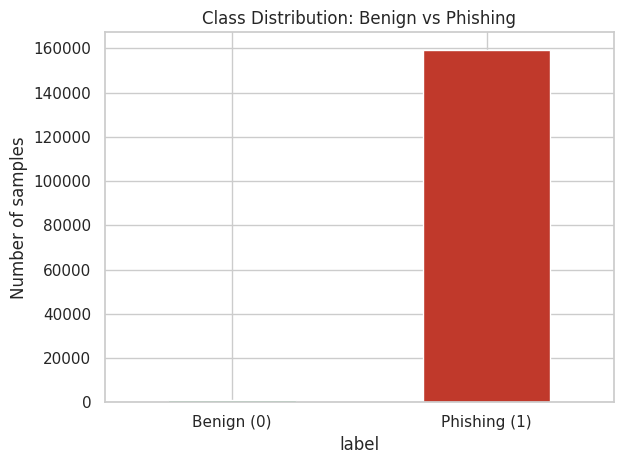

In [32]:
ax = df["label"].value_counts().sort_index().plot(kind="bar", color=["#27ae60", "#c0392b"])
ax.set_xticklabels(["Benign (0)", "Phishing (1)"], rotation=0)
ax.set_ylabel("Number of samples")
ax.set_title("Class Distribution: Benign vs Phishing")
plt.tight_layout()
plt.show()

> **Note on class imbalance.** Benign URLs make up only about 0.5% of this dataset, so a model
> that always predicts "phishing" would already score about 99.5% accuracy. This is why
> Section 9 reports imbalance-aware metrics and compares the trained models against an
> untrained reference, instead of relying on accuracy alone.

## 3. Data Cleaning
- Drop exact duplicate rows (and repeated `url` strings).
- Impute missing values in numeric columns with the column **median**.
- Drop any row missing `label` or `url`, since these cannot be used for supervised training.
- Identify and remove constant / zero-variance columns, which carry no discriminative information.
- Keep a copy of the raw `url` strings (indexed by row) for the Google Safe Browsing
  cross-check in Section 10, then drop `url` from the model inputs: it is a record
  identifier, not a usable numeric or categorical feature.

In [6]:
df_clean = df.copy()

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.drop_duplicates(subset="url", keep="first")
print(f"Removed {before - len(df_clean)} duplicate rows ({before} -> {len(df_clean)}).")

# Rows without a label/url cannot be used for supervised learning
df_clean = df_clean.dropna(subset=["label", "url"])

# Median imputation for remaining numeric gaps
num_cols_all = df_clean.select_dtypes(include=[np.number]).columns.drop("label")
df_clean[num_cols_all] = df_clean[num_cols_all].fillna(df_clean[num_cols_all].median())
df_clean["label"] = df_clean["label"].astype(int)

# Constant / zero-variance columns
constant_cols = [c for c in num_cols_all if df_clean[c].nunique() <= 1]
print("Zero-variance columns removed:", constant_cols if constant_cols else "None")
df_clean = df_clean.drop(columns=constant_cols)

# Sanity check: counts should not be negative
count_cols = [c for c in df_clean.select_dtypes(include=[np.number]).columns if c != "label"]
neg = (df_clean[count_cols] < 0).sum()
print("Columns with negative values (should be none):")
print(neg[neg > 0] if (neg > 0).any() else "None")

df_clean.reset_index(drop=True, inplace=True)

# Keep URL strings aside (same row index) for the Safe Browsing cross-check, then drop from model inputs
url_lookup = df_clean["url"].copy()
df_clean = df_clean.drop(columns=["url"])
print("Shape after cleaning:", df_clean.shape)

Removed 0 duplicate rows (160064 -> 160064).
Zero-variance columns removed: None
Columns with negative values (should be none):
None
Shape after cleaning: (160064, 12)


## 4. Feature Engineering
Two domain-informed features reinforce the base feature set:

- **`digit_ratio`**: the proportion of a URL's characters that are digits, a pattern
  commonly associated with obfuscated or randomly generated phishing addresses.
- **`risky_combo`**: a binary flag that activates only when a URL has **no HTTPS** *and*
  contains **at least one suspicious keyword**, combining two individually weaker signals
  into one more discriminative feature.

In [7]:
df_feat = df_clean.copy()

df_feat["digit_ratio"] = df_feat["digits_count"] / df_feat["url_length"].replace(0, 1)
df_feat["risky_combo"] = ((df_feat["has_https"] == 0) & (df_feat["suspicious_words"] > 0)).astype(int)

print("risky_combo counts by class (rows = label, cols = risky_combo):")
print(pd.crosstab(df_feat["label"], df_feat["risky_combo"]))
df_feat[["digit_ratio", "risky_combo"]].describe()

risky_combo counts by class (rows = label, cols = risky_combo):
risky_combo       0     1
label                    
0               817     3
1            158230  1014


,digit_ratio,risky_combo
count,160064.000000,160064.000000
mean,0.251101,0.006354
std,0.192864,0.079457
min,0.000000,0.000000
25%,0.068966,0.000000
50%,0.226744,0.000000
75%,0.437500,0.000000
max,0.796610,1.000000


## 5. Data Transformation
- Group infrequent top-level domains (`tld`) into a single `"other"` category, then
  one-hot encode `tld` to limit the number of sparse columns.
- Standardize continuous numeric features with `StandardScaler`. This is required, not
  just good practice: Logistic Regression is fit by gradient-based optimization, so
  features with large ranges (e.g. `url_length`, `digits_count`) would otherwise dominate
  the learned coefficients and slow convergence.
- The scaler is **fit on the training set only** (Section 7) and then applied to the test
  set, so no information from the test data leaks into training.

In [8]:
df_trans = df_feat.copy()

n_missing_tld = int(df_trans["tld"].isnull().sum())
top_tlds = df_trans["tld"].value_counts().nlargest(6).index
df_trans["tld"] = df_trans["tld"].where(df_trans["tld"].isin(top_tlds), "other")
# Missing tld values are not in top_tlds, so they are assigned to "other" here
print(f"Missing tld values assigned to 'other': {n_missing_tld}")
df_trans = pd.get_dummies(df_trans, columns=["tld"], prefix="tld", dtype=int)

target_col = "label"
feature_cols = [c for c in df_trans.columns if c != target_col]

# Continuous columns to be standardized (binary / one-hot columns are left as-is)
SCALE_CANDIDATES = ["url_length", "num_dots", "num_subdirs", "num_params", "suspicious_words",
                    "special_char_count", "digits_count", "entropy", "digit_ratio"]
numeric_cols_to_scale = [c for c in SCALE_CANDIDATES if c in feature_cols]

print("Feature columns:", feature_cols)
print("Columns to scale:", numeric_cols_to_scale)
df_trans.head()

Missing tld values assigned to 'other': 821
Feature columns: ['url_length', 'num_dots', 'has_https', 'has_ip', 'num_subdirs', 'num_params', 'suspicious_words', 'special_char_count', 'digits_count', 'entropy', 'digit_ratio', 'risky_combo', 'tld_202', 'tld_227', 'tld_34', 'tld_com', 'tld_de', 'tld_other', 'tld_ru']
Columns to scale: ['url_length', 'num_dots', 'num_subdirs', 'num_params', 'suspicious_words', 'special_char_count', 'digits_count', 'entropy', 'digit_ratio']


,label,url_length,num_dots,has_https,has_ip,num_subdirs,num_params,suspicious_words,special_char_count,digits_count,entropy,digit_ratio,risky_combo,tld_202,tld_227,tld_34,tld_com,tld_de,tld_other,tld_ru
0,1,89,3,0,0,5,0,2,4,29,4.792985,0.325843,1,0,0,0,1,0,0,0
1,1,25,1,0,0,4,0,0,0,7,4.003856,0.280000,0,0,0,0,1,0,0,0
2,1,30,1,0,0,4,0,0,0,7,4.053236,0.233333,0,0,0,0,1,0,0,0
3,1,39,2,1,0,3,0,0,3,0,4.150411,0.000000,0,0,0,0,0,0,1,0
4,1,37,2,1,0,3,0,0,0,0,4.100817,0.000000,0,0,0,0,0,0,1,0


## 6. Feature Selection
The raw `url` text was already excluded in Section 3. The eleven lexical features from the
dataset (`url_length, num_dots, has_https, has_ip, num_subdirs, num_params,
suspicious_words, tld, special_char_count, digits_count, entropy`) are retained as the base
set, plus the two engineered features.

A correlation analysis of the numeric features flags redundant pairs (|r| > 0.9). The
trained model's **coefficient magnitudes** (Section 9) are then used to interpret which
features contribute most to the predicted log-odds of a URL being phishing.

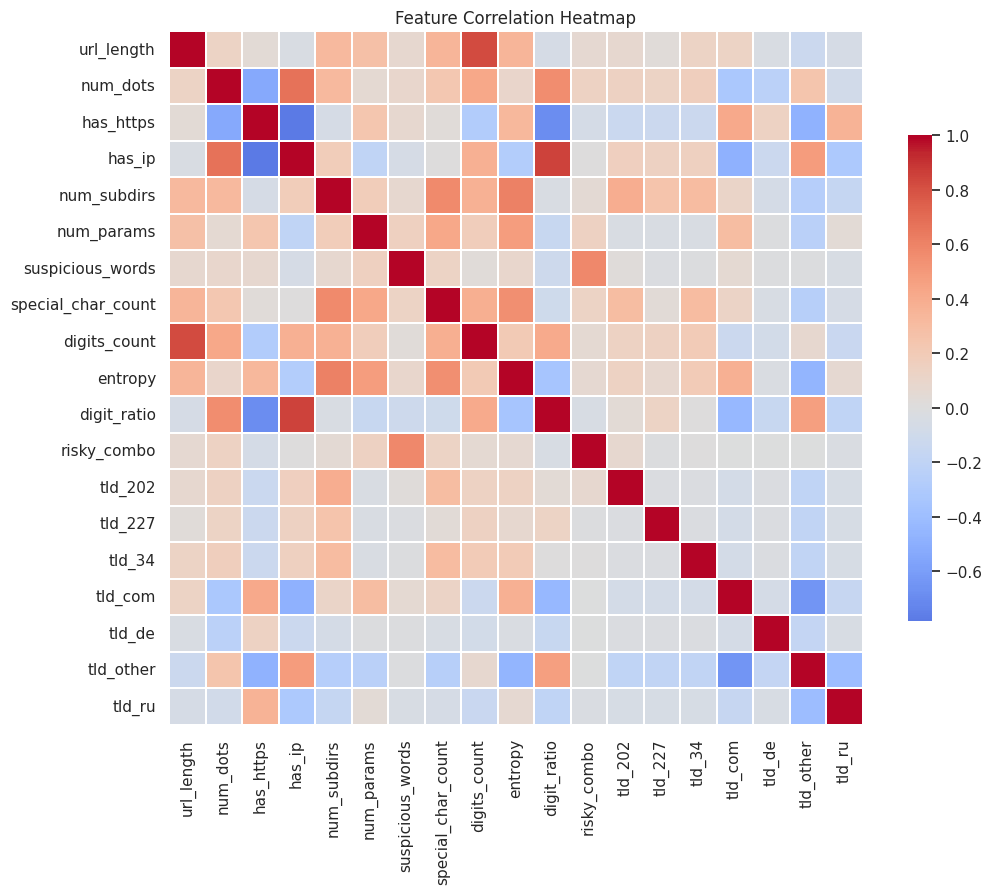

Highly correlated feature pairs (|r| > 0.9):
None found.


In [9]:
plt.figure(figsize=(11, 9))
corr = df_trans[feature_cols].select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.3, cbar_kws={"shrink": 0.7})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .pipe(lambda s: s[s.abs() > 0.9])
)
print("Highly correlated feature pairs (|r| > 0.9):")
print(high_corr if not high_corr.empty else "None found.")

## 7. Data Splitting and Scaling
Stratified train/test split (80% train, 20% test) to preserve the phishing/benign ratio
in both sets, then `StandardScaler` fit **only on the training set**. Stratified 5-fold
cross-validation is set up for a more robust performance estimate during evaluation and tuning.

In [10]:
X = df_trans[feature_cols]
y = df_trans[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols_to_scale] = scaler.fit_transform(X_train[numeric_cols_to_scale])
X_test_scaled[numeric_cols_to_scale] = scaler.transform(X_test[numeric_cols_to_scale])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")
print("Train class balance:")
print(y_train.value_counts(normalize=True).sort_index())
print("Test class counts (0 = benign, 1 = phishing):")
print(y_test.value_counts().sort_index())

Train shape: (128051, 19), Test shape: (32013, 19)
Train class balance:
label
0    0.005123
1    0.994877
Name: proportion, dtype: float64
Test class counts (0 = benign, 1 = phishing):
label
0      164
1    31849
Name: count, dtype: int64


## 8. Model Development — Logistic Regression Binary Classifier
Two configurations are trained and compared:

- **Configuration 1 (Baseline):** default regularization (L2, C = 1.0), no class weighting.
- **Configuration 2 (Tuned):** `GridSearchCV` over C ∈ {0.01, 0.1, 1, 10} (scored by F1)
  combined with `class_weight="balanced"` to address the severe class imbalance.

The target has exactly two classes (`0` = benign, `1` = phishing), so this is a binary
classification model and precision / recall / F1 are computed with phishing as the
positive class.

### 8.0 Model formula
Logistic Regression models the probability that a URL is phishing as a sigmoid of a weighted sum of its features:

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n \qquad P(\text{phishing}\mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

A URL is classified as phishing when $P(\text{phishing}\mid x) > 0.5$ (the scikit-learn default threshold).

scikit-learn fits the weights by minimizing the regularized objective

$$\min_{\beta}\ \tfrac{1}{2}\lVert\beta\rVert^2 + C \sum_{i=1}^{n} w_i\, L_i, \qquad L_i = -y_i \ln p_i - (1-y_i)\ln(1-p_i)$$

- $L_i$ is the log-loss for URL $i$. The term $\tfrac12\lVert\beta\rVert^2$ is the L2 penalty (the intercept $\beta_0$ is not penalized), and a larger $C$ means weaker regularization.
- $w_i = 1$ for every URL in Configuration 1.
- In Configuration 2, `class_weight="balanced"` sets $w_i = n / (2\,n_k)$, where $n_k$ is the number of training URLs in the class of URL $i$ (about 97.6 for benign and 0.50 for phishing in this dataset).
- In the run documented here, the grid search selected $C = 1$ (see Section 8.2), so the two configurations differ only in class weighting.

### 8.0b Evaluation helper function

In [11]:
assert y_train.nunique() == 2 and y_test.nunique() == 2, "Expected exactly 2 classes for binary classification."

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """Fit, then report held-out test metrics (6 decimals so tiny differences stay visible)."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_proba)
    cm = confusion_matrix(y_te, y_pred)
    print(f"=== {name}: HELD-OUT TEST SET ===")
    print(f"Accuracy : {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall   : {rec:.6f}")
    print(f"F1-score : {f1:.6f}")
    print(f"ROC-AUC  : {auc:.6f}")
    print("Confusion Matrix (rows=actual, cols=predicted):")
    print("                Pred Benign  Pred Phishing")
    print(f"Actual Benign   {cm[0][0]:<12} {cm[0][1]}")
    print(f"Actual Phishing {cm[1][0]:<12} {cm[1][1]}")
    return {"model": model, "acc": acc, "prec": prec, "rec": rec, "f1": f1, "auc": auc, "cm": cm}

### 8.1 Configuration 1 — Baseline
Evaluated first with 5-fold stratified cross-validation on the training set, then on the held-out test set.

In [12]:
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                    C=1.0, penalty="l2", class_weight=None)

cv_scores_baseline = cross_validate(
    baseline_model, X_train_scaled, y_train, cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)
print("Config 1 — 5-fold stratified CV on training set (mean ± std):")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    s = cv_scores_baseline[f"test_{metric}"]
    print(f"  {metric:10s}: {s.mean():.6f} ± {s.std():.6f}")
print()

result1 = evaluate("CONFIGURATION 1 (Baseline)", baseline_model,
                   X_train_scaled, y_train, X_test_scaled, y_test)

Config 1 — 5-fold stratified CV on training set (mean ± std):
  accuracy  : 1.000000 ± 0.000000
  precision : 1.000000 ± 0.000000
  recall    : 1.000000 ± 0.000000
  f1        : 1.000000 ± 0.000000
  roc_auc   : 1.000000 ± 0.000000

=== CONFIGURATION 1 (Baseline): HELD-OUT TEST SET ===
Accuracy : 1.000000
Precision: 1.000000
Recall   : 1.000000
F1-score : 1.000000
ROC-AUC  : 1.000000
Confusion Matrix (rows=actual, cols=predicted):
                Pred Benign  Pred Phishing
Actual Benign   164          0
Actual Phishing 0            31849


### 8.2 Configuration 2 — Tuned and class-balanced
Hyperparameter tuning of the regularization strength C via `GridSearchCV`, with
`class_weight="balanced"` so that errors on the minority (benign) class are penalized more heavily.

In [13]:
param_grid = {"C": [0.01, 0.1, 1, 10]}

tuned_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                       class_weight="balanced", penalty="l2", solver="lbfgs"),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)
tuned_search.fit(X_train_scaled, y_train)
print("Best hyperparameters found:", tuned_search.best_params_)
print(f"Best CV F1-score during search: {tuned_search.best_score_:.6f}")
print()

best_model = tuned_search.best_estimator_
result2 = evaluate("CONFIGURATION 2 (Tuned)", best_model,
                   X_train_scaled, y_train, X_test_scaled, y_test)

Best hyperparameters found: {'C': 1}
Best CV F1-score during search: 0.999961

=== CONFIGURATION 2 (Tuned): HELD-OUT TEST SET ===
Accuracy : 0.999969
Precision: 1.000000
Recall   : 0.999969
F1-score : 0.999984
ROC-AUC  : 1.000000
Confusion Matrix (rows=actual, cols=predicted):
                Pred Benign  Pred Phishing
Actual Benign   164          0
Actual Phishing 1            31848


## 9. Evaluation
Expected evaluation metrics for this project: **accuracy, precision, recall, F1-score, a
confusion matrix**, and **ROC-AUC**, plus a **coefficient ranking** to interpret which URL
characteristics drive the model's predictions.

Recall on the phishing class is emphasized: a missed phishing URL (false negative) has a
higher real-world security cost than a false alarm (false positive).

### 9.0 Metrics summary and classification reports

In [14]:
print(f"{'Metric':<12}{'Config 1 (Baseline)':<22}{'Config 2 (Tuned)':<20}")
for metric_name, key in [("Accuracy", "acc"), ("Precision", "prec"),
                         ("Recall", "rec"), ("F1-score", "f1"), ("ROC-AUC", "auc")]:
    print(f"{metric_name:<12}{result1[key]:<22.6f}{result2[key]:<20.6f}")
print()
for name, res in [("Config 1 (Baseline)", result1), ("Config 2 (Tuned)", result2)]:
    print(f"--- {name} ---")
    print(classification_report(y_test, res["model"].predict(X_test_scaled),
                                target_names=["Benign", "Phishing"], digits=6))

Metric      Config 1 (Baseline)   Config 2 (Tuned)    
Accuracy    1.000000              0.999969            
Precision   1.000000              1.000000            
Recall      1.000000              0.999969            
F1-score    1.000000              0.999984            
ROC-AUC     1.000000              1.000000            

--- Config 1 (Baseline) ---
              precision    recall  f1-score   support

      Benign   1.000000  1.000000  1.000000       164
    Phishing   1.000000  1.000000  1.000000     31849

    accuracy                       1.000000     32013
   macro avg   1.000000  1.000000  1.000000     32013
weighted avg   1.000000  1.000000  1.000000     32013

--- Config 2 (Tuned) ---
              precision    recall  f1-score   support

      Benign   0.993939  1.000000  0.996960       164
    Phishing   1.000000  0.999969  0.999984     31849

    accuracy                       0.999969     32013
   macro avg   0.996970  0.999984  0.998472     32013
weighted avg   0.

### 9.1 Confusion matrices

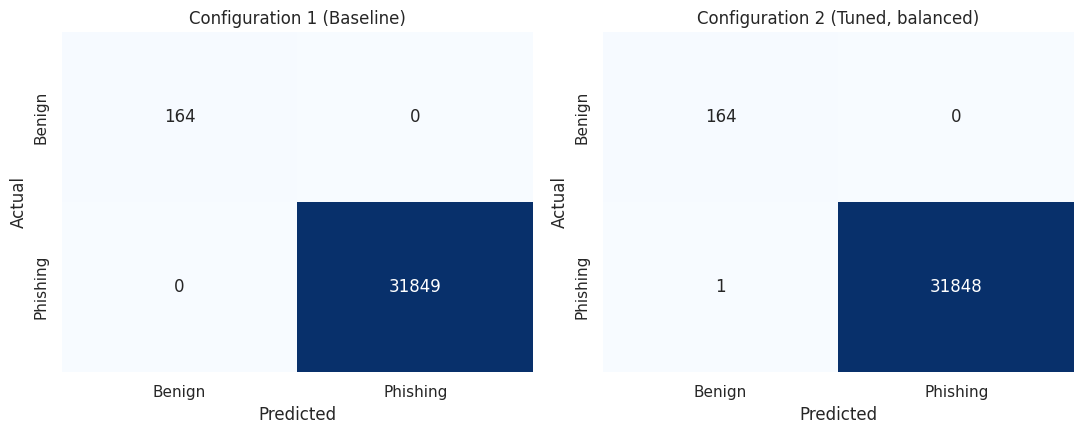

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, res, title in zip(axes, [result1, result2],
                          ["Configuration 1 (Baseline)", "Configuration 2 (Tuned, balanced)"]):
    sns.heatmap(res["cm"], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Benign", "Phishing"], yticklabels=["Benign", "Phishing"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
plt.tight_layout()
plt.show()

### 9.2 ROC curve comparison

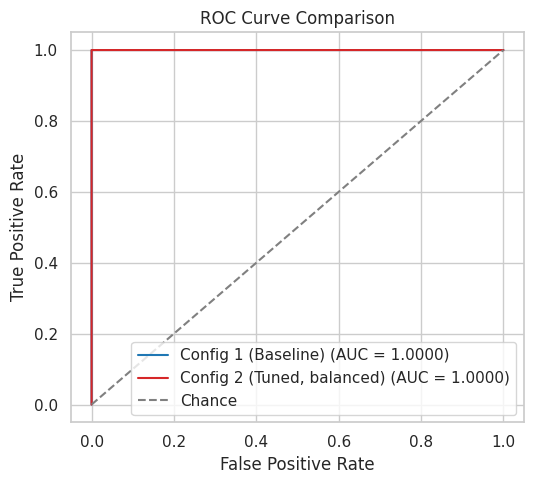

In [16]:
plt.figure(figsize=(5.5, 5))
for res, label, color in [(result1, "Config 1 (Baseline)", "#1f77b4"),
                          (result2, "Config 2 (Tuned, balanced)", "#d62728")]:
    proba = res["model"].predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_score(y_test, proba):.4f})", color=color)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

### 9.3 Trained models vs. an untrained reference
With ~99.5% phishing URLs, accuracy and F1 look excellent even for a model that learned
nothing. To show that training actually made a difference, both configurations are compared
against an **untrained reference** (`DummyClassifier` that always predicts the majority
class, "phishing") using imbalance-aware metrics: balanced accuracy, benign-class recall,
ROC-AUC, and Matthews correlation coefficient (MCC). The y-axis is shown in full (0 to 1.1)
with no cropping.

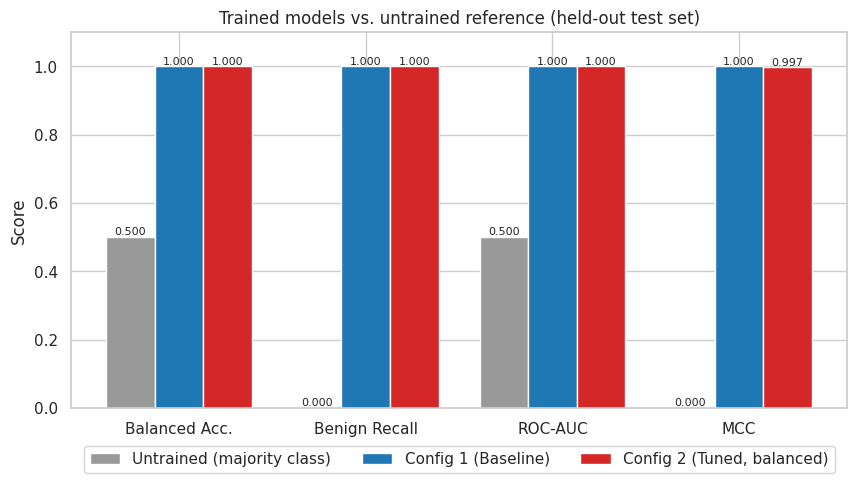

In [17]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train_scaled, y_train)

def metric_row(model):
    p = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    return [
        balanced_accuracy_score(y_test, p),
        recall_score(y_test, p, pos_label=0),     # benign-class recall
        roc_auc_score(y_test, proba),
        matthews_corrcoef(y_test, p),
    ]

labels = ["Balanced Acc.", "Benign Recall", "ROC-AUC", "MCC"]
rows = {
    "Untrained (majority class)": metric_row(dummy),
    "Config 1 (Baseline)": metric_row(result1["model"]),
    "Config 2 (Tuned, balanced)": metric_row(result2["model"]),
}

x = np.arange(len(labels)); w = 0.26
fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, vals) in enumerate(rows.items()):
    bars = ax.bar(x + (i - 1) * w, vals, w, label=name, color=["#999999", "#1f77b4", "#d62728"][i])
    ax.bar_label(bars, fmt="%.3f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Trained models vs. untrained reference (held-out test set)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3)
plt.tight_layout()
plt.show()

### 9.4 Error counts (where the two configurations actually differ)
Because both trained models score near 1.0, the clearest way to show the difference
between them is the raw number of mistakes.

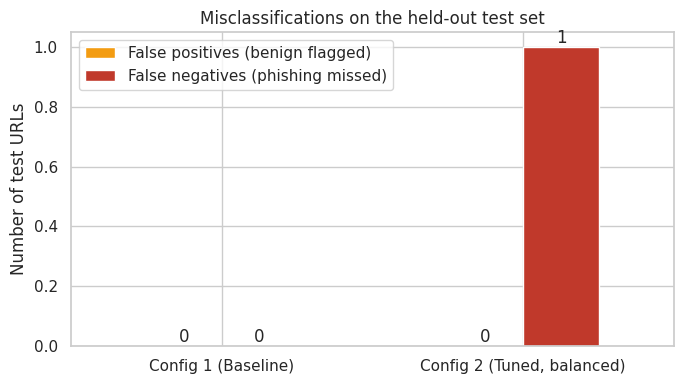

,Config 1 (Baseline),"Config 2 (Tuned, balanced)"
False positives (benign flagged),0,0
False negatives (phishing missed),0,1


In [18]:
err = pd.DataFrame({
    "Config 1 (Baseline)": [result1["cm"][0][1], result1["cm"][1][0]],
    "Config 2 (Tuned, balanced)": [result2["cm"][0][1], result2["cm"][1][0]],
}, index=["False positives (benign flagged)", "False negatives (phishing missed)"])

ax = err.T.plot(kind="bar", figsize=(7, 4), color=["#f39c12", "#c0392b"], rot=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%d")
ax.set_ylabel("Number of test URLs")
ax.set_title("Misclassifications on the held-out test set")
plt.tight_layout()
plt.show()
err

### 9.5 Which URL characteristics signal phishing? (coefficients)
Features are standardized, so coefficient magnitudes are directly comparable. Positive
coefficients push a URL toward **phishing**; negative ones push it toward **benign**.

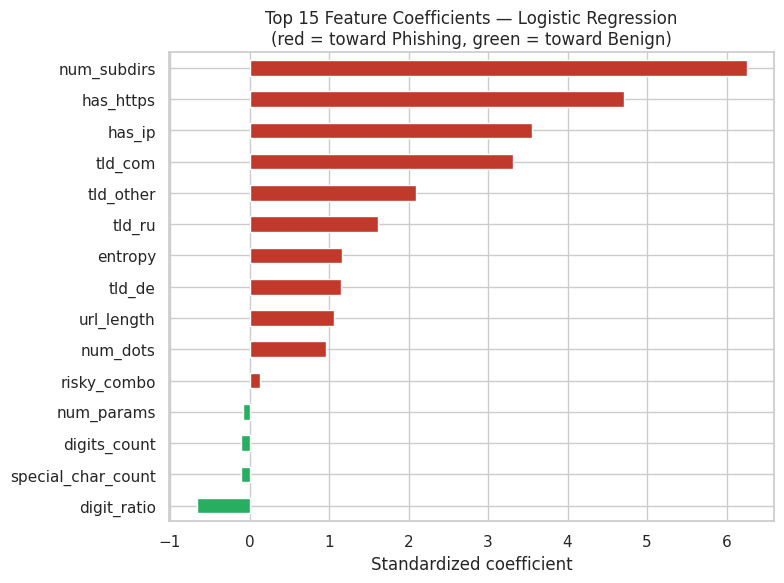

,0
num_subdirs,6.250924
has_https,4.705559
has_ip,3.550930
tld_com,3.310683
tld_other,2.094061
tld_ru,1.618480
entropy,1.168200
tld_de,1.156242
url_length,1.064513
num_dots,0.964465


In [19]:
chosen = result1["model"]   # baseline is the recommended model; swap to result2["model"] to compare
coefs = pd.Series(chosen.coef_[0], index=feature_cols)
importances = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

top = importances.head(15).sort_values()
colors = top.apply(lambda v: "#c0392b" if v > 0 else "#27ae60")
plt.figure(figsize=(8, 6))
top.plot(kind="barh", color=colors)
plt.title("Top 15 Feature Coefficients — Logistic Regression\n(red = toward Phishing, green = toward Benign)")
plt.xlabel("Standardized coefficient")
plt.tight_layout()
plt.show()

importances.head(15)

## 9.6 Data audit: checking for dataset artifacts
Near-perfect scores are unusual, so the checks below look for properties of the dataset that
could make the two classes easy to separate for reasons unrelated to phishing itself.

### 9.6.1 Missing top-level domain (TLD) vs. class

In [20]:
print("Crosstab of missing TLD values vs. Target label:")
print(pd.crosstab(df["tld"].isnull(), df["label"],
                  rownames=["tld missing"], colnames=["label"]))

Crosstab of missing TLD values vs. Target label:
label          0       1
tld missing             
False          0  159243
True         820       1


### 9.6.2 URL format check: does the URL start with `http://` or `https://`?

In [21]:
has_scheme = df["url"].str.startswith(("http://", "https://"))
print(pd.crosstab(has_scheme, df["label"], rownames=["has http(s)://"], colnames=["label"]))

label             0       1
has http(s)://             
False           820       0
True              0  159244


### 9.6.3 TLD-removal test
Configuration 1 is retrained without any TLD-derived columns to see whether the model
depended on the missing-TLD pattern. The first table shows how many benign and phishing URLs
fall in the `tld_other` category (which also contains missing TLD values).

In [22]:
tld_cols = [c for c in X_train_scaled.columns if c.startswith("tld_")]

# How well does tld_other alone mark benign URLs?
print(pd.crosstab(X["tld_other"], y, rownames=["tld_other"], colnames=["label"]))

# Retrain Config 1 without any TLD columns
abl = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
abl.fit(X_train_scaled.drop(columns=tld_cols), y_train)
Xte = X_test_scaled.drop(columns=tld_cols)
pred = abl.predict(Xte)

print(confusion_matrix(y_test, pred))
print("Benign recall:", recall_score(y_test, pred, pos_label=0))
print("Phishing recall:", recall_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, abl.predict_proba(Xte)[:, 1]))

label        0      1
tld_other            
0            0  60742
1          820  98502
[[  164     0]
 [    0 31849]]
Benign recall: 1.0
Phishing recall: 1.0
ROC-AUC: 1.0


### 9.6.4 Audit findings (from the run on the full dataset)
- **Missing TLD:** all 820 benign URLs have a missing `tld`, compared with 1 of 159,244 phishing URLs.
- **URL format:** all 820 benign URLs lack an `http://` or `https://` prefix, while all 159,244 phishing URLs have one.
- **TLD-removal test:** retraining Configuration 1 without any TLD columns gave identical results (confusion matrix `[[164, 0], [0, 31849]]`, benign recall 1.0, phishing recall 1.0, ROC-AUC 1.0). `tld_other` alone does not give the answer away, because it holds all 820 benign URLs and 98,502 phishing URLs.
- **Interpretation:** the model does not depend on the TLD pattern alone, but features such as `num_subdirs`, `has_https` and `has_ip` still carry much of the URL-format difference (they have among the largest coefficients in Section 9.5). The perfect separation most likely reflects how the dataset was built, so treat the results as a proof of concept on this dataset.

### 9.7 Verification that the models were trained
A scikit-learn model only has `coef_` after it has been fitted, so the first checks confirm both
models were trained and show how many weights each learned. The AUC comparison then shows the
effect of training: the untrained reference scores 0.5 (random guessing), while the trained models score about 1.0.

In [23]:
print("Config 1 trained:", hasattr(result1["model"], "coef_"))
print("Config 2 trained:", hasattr(result2["model"], "coef_"))
print("Number of learned weights:", result1["model"].coef_.shape[1])
print("Untrained AUC :", roc_auc_score(y_test, dummy.predict_proba(X_test_scaled)[:,1]))
print("Config 1 AUC  :", roc_auc_score(y_test, result1["model"].predict_proba(X_test_scaled)[:,1]))
print("Config 2 AUC  :", roc_auc_score(y_test, result2["model"].predict_proba(X_test_scaled)[:,1]))

Config 1 trained: True
Config 2 trained: True
Number of learned weights: 19
Untrained AUC : 0.5
Config 1 AUC  : 0.9999999999999999
Config 2 AUC  : 1.0


### 9.8 Learning curve
Configuration 1 is retrained on progressively larger random subsets of the training data and
evaluated on the same held-out test set. If the score rises with more training data, the model is learning.
The two smallest subsets contain only 3 benign URLs each, so their scores are noisy; the trend from about
100 training URLs onward is the reliable part.

   train_size  balanced_acc  benign_recall     mcc
0          10        0.9968         1.0000  0.6627
1          30        0.8384         0.6768  0.8220
2         100        0.9998         1.0000  0.9707
3         500        1.0000         1.0000  0.9939
4        2000        1.0000         1.0000  1.0000
5      128051        1.0000         1.0000  1.0000


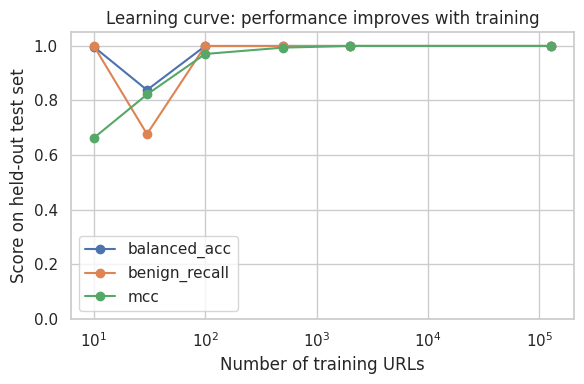

In [24]:
sizes = [10, 30, 100, 500, 2000, len(X_train_scaled)]
benign_idx = np.where(y_train.values == 0)[0]
phish_idx = np.where(y_train.values == 1)[0]
rng = np.random.RandomState(RANDOM_STATE)

rows = []
for n in sizes:
    if n == len(X_train_scaled):
        idx = np.arange(n)
    else:
        nb = min(max(3, n // 10), len(benign_idx))      # keep ~10% benign so both classes appear
        idx = np.concatenate([rng.choice(benign_idx, nb, replace=False),
                              rng.choice(phish_idx, n - nb, replace=False)])
    m = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(
        X_train_scaled.iloc[idx], y_train.iloc[idx])
    p = m.predict(X_test_scaled)
    rows.append([n, balanced_accuracy_score(y_test, p),
                 recall_score(y_test, p, pos_label=0), matthews_corrcoef(y_test, p)])

lc = pd.DataFrame(rows, columns=["train_size", "balanced_acc", "benign_recall", "mcc"])
print(lc.round(4))

plt.figure(figsize=(6, 4))
for c in ["balanced_acc", "benign_recall", "mcc"]:
    plt.plot(lc["train_size"], lc[c], marker="o", label=c)
plt.xscale("log"); plt.ylim(0, 1.05)
plt.xlabel("Number of training URLs"); plt.ylabel("Score on held-out test set")
plt.title("Learning curve: performance improves with training")
plt.legend(); plt.tight_layout(); plt.show()

### 9.9 Limitations to keep in mind
- Near-perfect scores on a ~99.5% phishing dataset can mean the features separate the
  classes unusually cleanly (or that the dataset is easy / has labeling artefacts). Treat
  these numbers as a best-case demonstration, not a deployment-ready result.
- Only ~0.5% of the test set is benign (a few hundred rows at most), so a handful of
  samples decides benign-class recall.
- The model only sees the eleven lexical features; it does not inspect page content,
  WHOIS records or network traffic.
- A data audit found that all 820 benign URLs lack an http:// or https:// prefix while all 159,244 phishing URLs include one, and all benign URLs also have a missing TLD value. Removing the TLD features did not change performance, but other features (e.g. num_subdirs, has_https, has_ip) still encode this URL-format difference. The near-perfect scores therefore most likely reflect how the dataset was built and may not carry over to URLs from other sources.

## 10. Prediction Demo and Google Safe Browsing Cross-Check
The model should take an unseen URL's features and return both a class prediction and a
probability. The cell below samples URLs from the held-out test set, shows the model's
prediction and phishing probability next to the dataset label, and produces a table you can
use for the **manual cross-check against Google Safe Browsing** described in the Expected
Results section (https://transparencyreport.google.com/safe-browsing/search).

> Do **not** open suspicious URLs in a browser. Paste them into the Safe Browsing
> transparency checker instead, and record the verdict in the `safe_browsing_verdict` column.

### 10.1 Sample test URLs
Ten URLs are drawn at random from the held-out test set (5 benign and 5 phishing by dataset label,
fixed seed) and shown with the model's prediction and phishing probability.

In [25]:
SAMPLE_PER_CLASS = 5
final_model = result1["model"]

proba_test = final_model.predict_proba(X_test_scaled)[:, 1]
pred_test = final_model.predict(X_test_scaled)

demo = pd.DataFrame({
    "url": url_lookup.loc[X_test_scaled.index].values,
    "dataset_label": y_test.values,
    "model_prediction": pred_test,
    "phishing_probability": proba_test.round(4),
}, index=X_test_scaled.index)

picks = []
for lbl in (0, 1):
    pool = demo[demo["dataset_label"] == lbl]
    picks.append(pool.sample(n=min(SAMPLE_PER_CLASS, len(pool)), random_state=RANDOM_STATE))
safe_browsing_sample = pd.concat(picks).reset_index(drop=True)
safe_browsing_sample["safe_browsing_verdict"] = ""   # fill in manually after checking

safe_browsing_sample

,url,dataset_label,model_prediction,phishing_probability,safe_browsing_verdict
0,un.org,0,0,0.0028,
1,university92.edu,0,0,0.0244,
2,terraform.io,0,0,0.0086,
3,safeexample50.net,0,0,0.0187,
4,amd.com,0,0,0.0024,
5,http://182.116.11.31:57515/bin.sh,1,1,1.0000,
6,https://novoacesso.ru.com/,1,1,1.0000,
7,https://zoll-de97042.web.app/,1,1,1.0000,
8,https://menuwerm.firebaseapp.com/,1,1,1.0000,
9,https://sprng9.fr0gtime.ru/0ex5imjd,1,1,1.0000,


### 10.2 Record the Safe Browsing verdicts
Each sampled URL was pasted into Google's Safe Browsing site status checker and the result was typed in below.
Verdicts are matched to URLs, not to row positions, so they stay correct even if the table order changes.

In [26]:
# Verdicts recorded manually from Google's Safe Browsing site status checker:
#   "unsafe"      = Google shows a warning for this URL
#   "not flagged" = "No unsafe content found" (absence of a warning, NOT proof the URL is safe)
#   "no data"     = Google has no information about this URL
safe_browsing_verdicts = {
    "un.org": "not flagged",
    "university92.edu": "no data",
    "terraform.io": "not flagged",
    "safeexample50.net": "no data",
    "amd.com": "not flagged",
    "http://182.116.11.31:57515/bin.sh": "not flagged",
    "https://novoacesso.ru.com/": "unsafe",
    "https://zoll-de97042.web.app/": "not flagged",
    "https://menuwerm.firebaseapp.com/": "not flagged",
    "https://sprng9.fr0gtime.ru/0ex5imjd": "not flagged",
}

# Matching by URL (not by row number) keeps each verdict attached to the right URL
safe_browsing_sample["safe_browsing_verdict"] = (
    safe_browsing_sample["url"].map(safe_browsing_verdicts).fillna("not checked")
)
n_unchecked = int((safe_browsing_sample["safe_browsing_verdict"] == "not checked").sum())
if n_unchecked:
    print(f"[warning] {n_unchecked} sampled URL(s) have no recorded verdict. The sample changed, "
          "so check them manually and add them to the dictionary above.\n")

safe_browsing_sample["model_says"] = safe_browsing_sample["model_prediction"].map({0: "benign", 1: "phishing"})

print(pd.crosstab(safe_browsing_sample["model_says"], safe_browsing_sample["safe_browsing_verdict"]))
flagged = safe_browsing_sample[safe_browsing_sample["safe_browsing_verdict"] == "unsafe"]
print(f"\nSafe Browsing flagged {len(flagged)} of {len(safe_browsing_sample)} sampled URLs; "
      f"the model predicted phishing for {(flagged['model_prediction'] == 1).sum()} of them.")
safe_browsing_sample

safe_browsing_verdict  no data  not flagged  unsafe
model_says                                         
benign                       2            3       0
phishing                     0            4       1

Safe Browsing flagged 1 of 10 sampled URLs; the model predicted phishing for 1 of them.


,url,dataset_label,model_prediction,phishing_probability,safe_browsing_verdict,model_says
0,un.org,0,0,0.0028,not flagged,benign
1,university92.edu,0,0,0.0244,no data,benign
2,terraform.io,0,0,0.0086,not flagged,benign
3,safeexample50.net,0,0,0.0187,no data,benign
4,amd.com,0,0,0.0024,not flagged,benign
5,http://182.116.11.31:57515/bin.sh,1,1,1.0000,not flagged,phishing
6,https://novoacesso.ru.com/,1,1,1.0000,unsafe,phishing
7,https://zoll-de97042.web.app/,1,1,1.0000,not flagged,phishing
8,https://menuwerm.firebaseapp.com/,1,1,1.0000,not flagged,phishing
9,https://sprng9.fr0gtime.ru/0ex5imjd,1,1,1.0000,not flagged,phishing


### 10.3 Interpreting the cross-check
- Safe Browsing flagged **1** of the 10 URLs (`novoacesso.ru.com`), and the model also predicted phishing for it.
- No URL that the model predicted as benign was flagged.
- "Not flagged" means only that Google shows no current warning; it is not proof that a URL is safe. Phishing sites are often removed or not yet listed, so unflagged phishing-labelled URLs are not treated as model errors.
- Two benign-labelled URLs (`university92.edu`, `safeexample50.net`) returned no data.
- With only 10 URLs this is a sanity check, not an accuracy measure.

## 11. Save Model
Persist the trained model and preprocessing components so they can be reloaded for
evaluation or used in a simple inference script. Configuration 1 (baseline) is saved as the
recommended model; change `result1` to `result2` below to save the tuned model instead.

In [27]:
os.makedirs("artifacts", exist_ok=True)
joblib.dump(result1["model"], "artifacts/logistic_regression_phishing_model.joblib")
joblib.dump(scaler, "artifacts/feature_scaler.joblib")
joblib.dump(feature_cols, "artifacts/feature_columns.joblib")
joblib.dump(numeric_cols_to_scale, "artifacts/scaled_columns.joblib")
print("Saved model, scaler, and feature column lists to ./artifacts/")

Saved model, scaler, and feature column lists to ./artifacts/


## Summary
- **Models:** at 4 decimals the two configurations look identical; at 6 decimals they differ by one misclassified URL. Configuration 1 (baseline) had already separated the benign class, so `class_weight="balanced"` could only nudge the decision boundary. Tuning and imbalance correction must be validated against a simple baseline, not assumed to help.
- **Training:** the untrained-reference comparison (Section 9.3), the `coef_` / AUC check (Section 9.7) and the learning curve (Section 9.8) show that the models learned a real signal.
- **Caveat:** the data audit (Section 9.6) found that benign and phishing URLs differ systematically in format (no `http(s)://` prefix and a missing TLD for every benign URL), so the near-perfect scores most likely reflect how the dataset was built. Treat them as a best-case proof of concept (see Section 9.9).
- **External check:** a small Google Safe Browsing sample (Section 10) did not conflict with the model, but it is too small to measure real-world accuracy.